# 03 — BL Lac Gamma-Ray Luminosity Function

BL Lac objects are blazars with jets aligned toward the observer, dominating
the unresolved gamma-ray background at high energies ($E > 10$ GeV).
Their luminosity function follows the LDDE parameterization of
Ajello et al. (2014), with an inverse-sum evolution.

**References:**

1. `docs/equations.md` §5 (Eqs. 5.1–5.5)
2. Ajello+ (2014) Table 3

In [22]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [23]:
from hi_gamma_xcorr import astro_sources as astro, ebl

## 1. Local Luminosity Function (Eq. 5.2)

$$\frac{d\Phi}{d\log_{10}L} = \frac{A}{(L/L_c)^{\gamma_1} + (L/L_c)^{\gamma_2}}$$

BL Lac: $A=9.20\times10^{-11}$, $L_c=2.43\times10^{48}$ erg/s,
$\gamma_1=1.12$, $\gamma_2=3.71$ (Ajello+ 2014).

### LDDE Evolution (Eqs. 5.3--5.4)

The peak redshift is luminosity-dependent: $z_c(L) = z_c^* (L/L_\mathrm{ref})^\alpha$.
The evolution factor uses the inverse-sum form (**D12**):
$$e(z) = \left[r^{-p_1} + r^{-p_2}\right]^{-1},\qquad r = (1+z)/(1+z_c)$$
with $p_1 = 4.50$, $p_2 = -12.88$. At low $z$: $e \sim r^{p_1}$ (rises);
at high $z$: $e \sim r^{p_2}$ (steep decline).

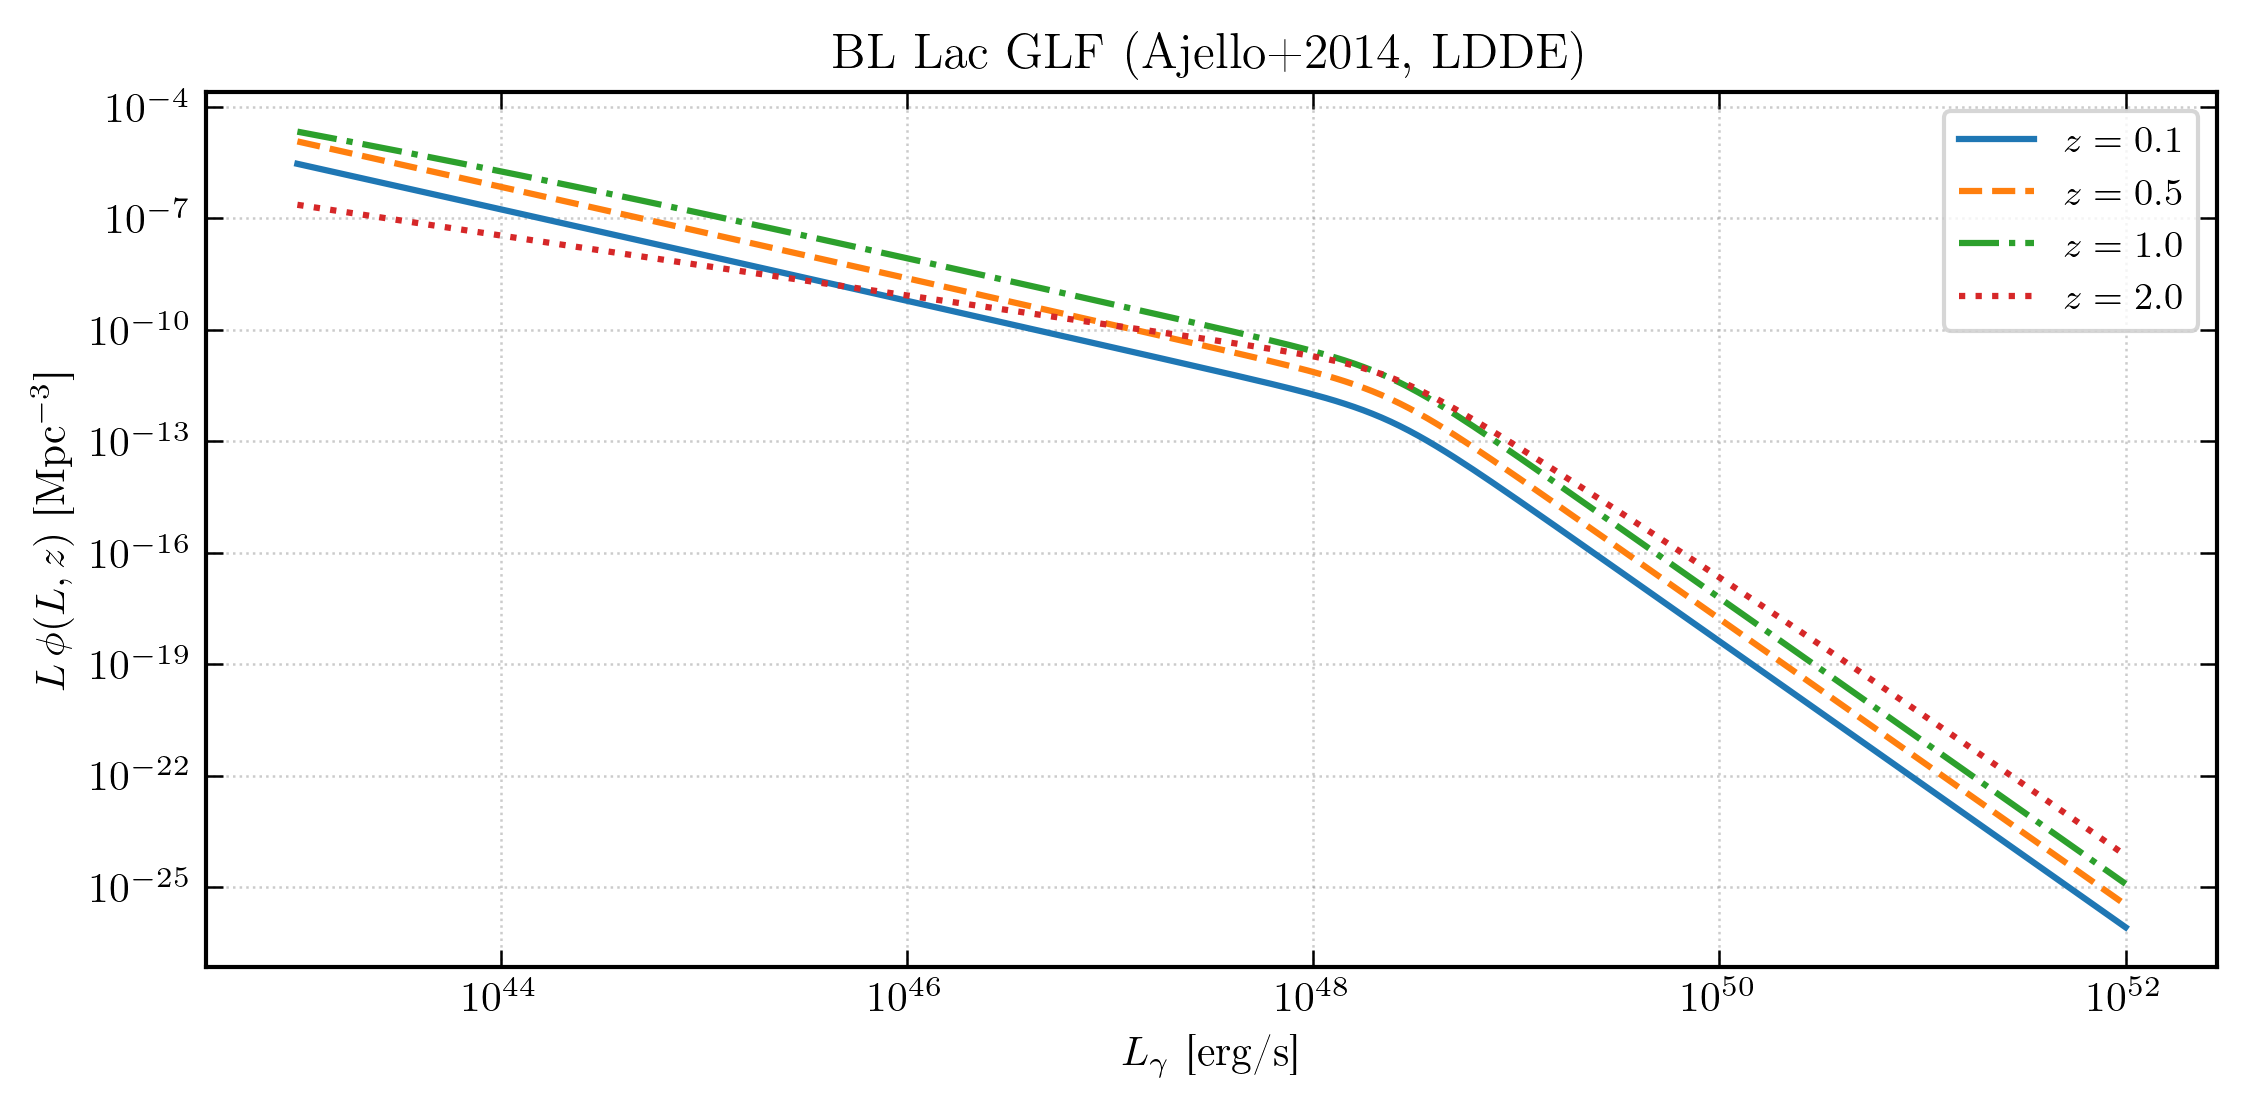

In [24]:
L_arr = np.logspace(43, 52, 200)
fig, ax = sty.textwidth_figure(8)
for z, ls in [(0.1, '-'), (0.5, '--'), (1.0, '-.'), (2.0, ':')]:
    phi = np.array([astro.glf(L, z, 'BL_Lac') for L in L_arr])
    ax.loglog(L_arr, L_arr * phi, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$L_\gamma$ [erg/s]'); ax.set_ylabel(r'$L\,\phi(L,z)$ [Mpc$^{-3}$]')
ax.set_title('BL Lac GLF (Ajello+2014, LDDE)')
ax.legend(); fig.tight_layout()

## 2. Fermi-LAT Detection Threshold (Eq. 5.1)

$L_\mathrm{sens}(z)$ separates resolved from unresolved sources.
Two baselines are shown: Pinetti constant $F_\mathrm{sens} = 10^{-10}$
cm$^{-2}$ s$^{-1}$ and the 4FGL-DR4 catalogue threshold (**D17**).

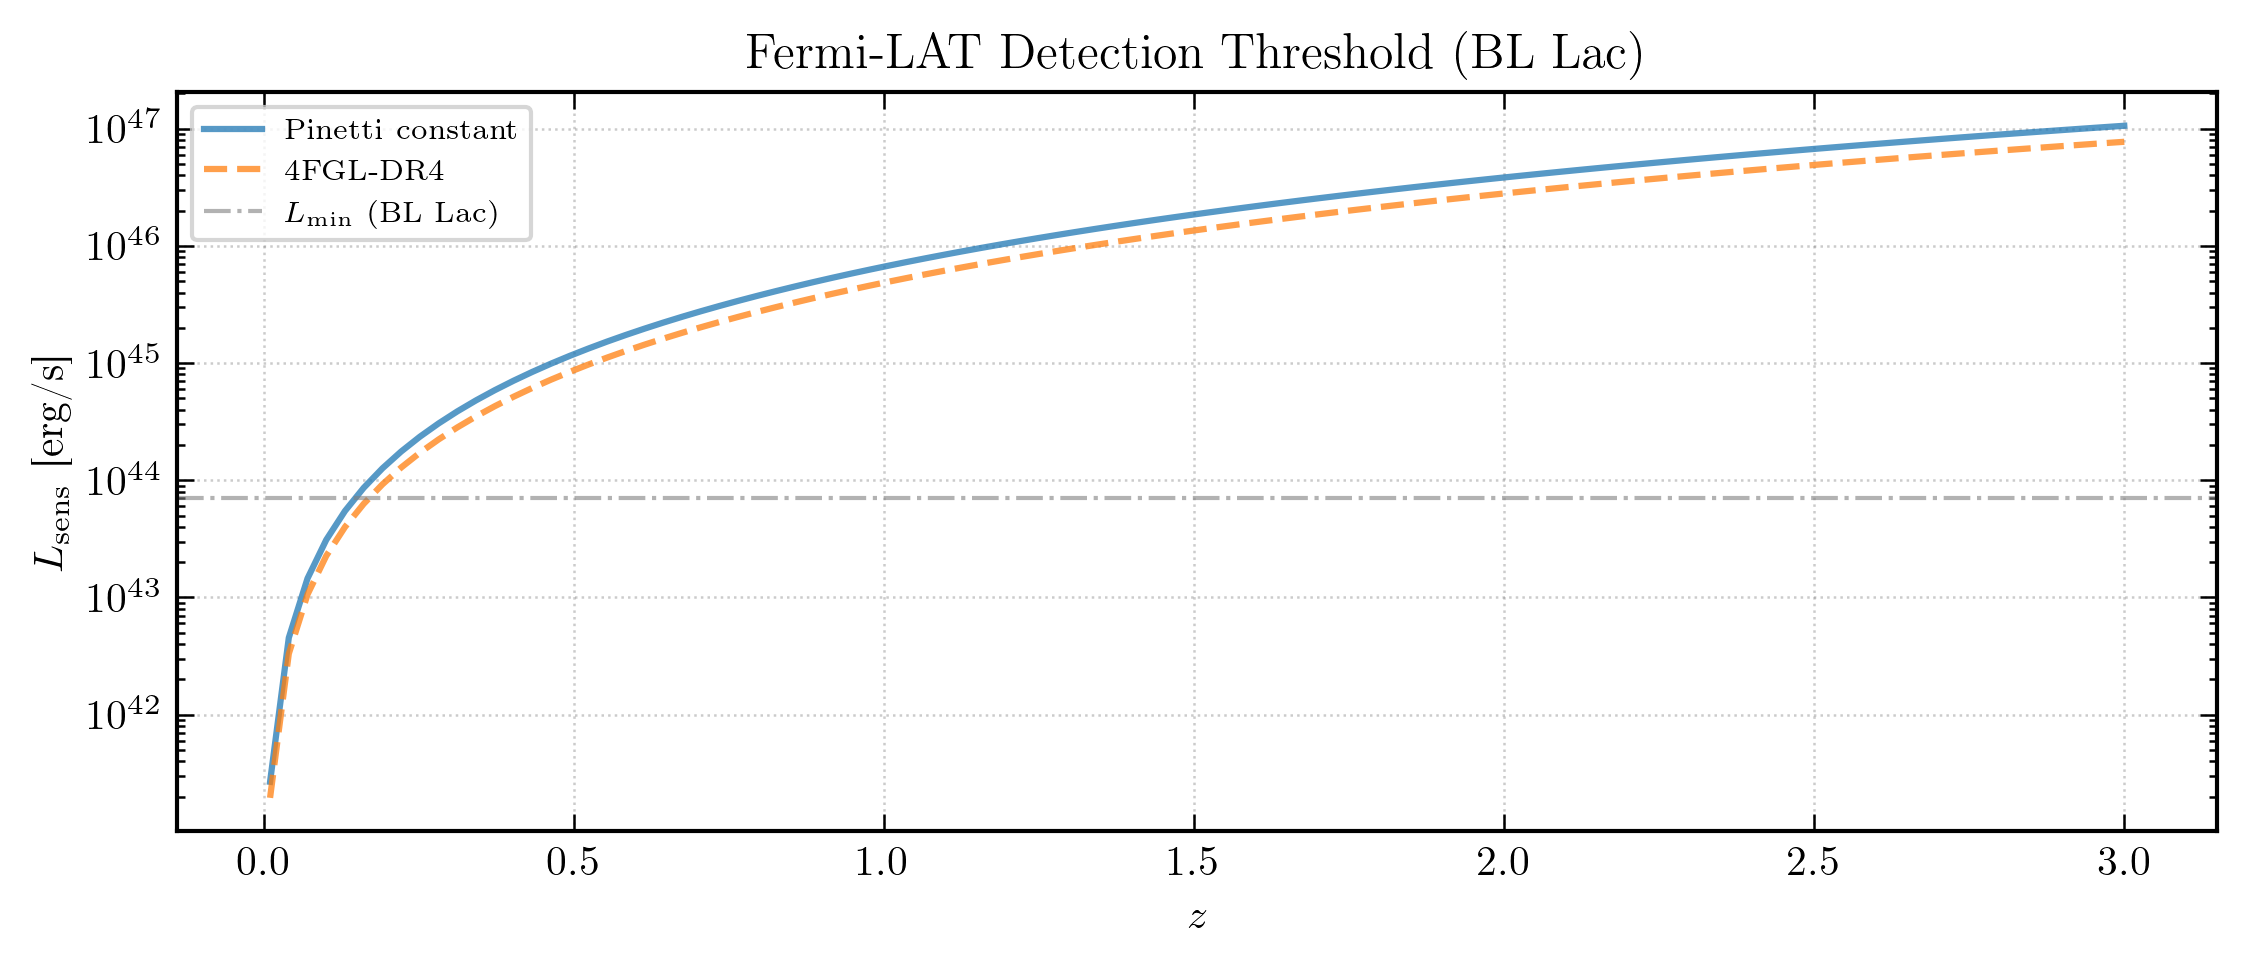

In [25]:
z_sens = np.linspace(0.01, 3.0, 100)
Ls_pin = np.array([astro.L_sens(z, alpha=2.11, F_sens_baseline=cfg.F_SENS_PINETTI) for z in z_sens])
Ls_4fgl = np.array([astro.L_sens(z, alpha=2.11, F_sens_baseline=cfg.F_SENS_4FGL_DR4) for z in z_sens])

fig, ax = sty.textwidth_figure(7)
ax.semilogy(z_sens, Ls_pin, **sty.FIT_STYLE, label='Pinetti constant')
ax.semilogy(z_sens, Ls_4fgl, **sty.MODEL_STYLE, label='4FGL-DR4')
ax.axhline(7e43, **sty.GUIDE_STYLE, label=r'$L_\mathrm{min}$ (BL Lac)')
ax.set_xlabel('$z$'); ax.set_ylabel(r'$L_\mathrm{sens}$ [erg/s]')
ax.set_title('Fermi-LAT Detection Threshold (BL Lac)'); ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

## 3. Window Function $W_\gamma^\mathrm{astro}$ (Eq. 5.5)

EBL attenuation $e^{-\tau}$ is applied at the observed energy (**D14**: thesis
omitted EBL for astrophysical windows).

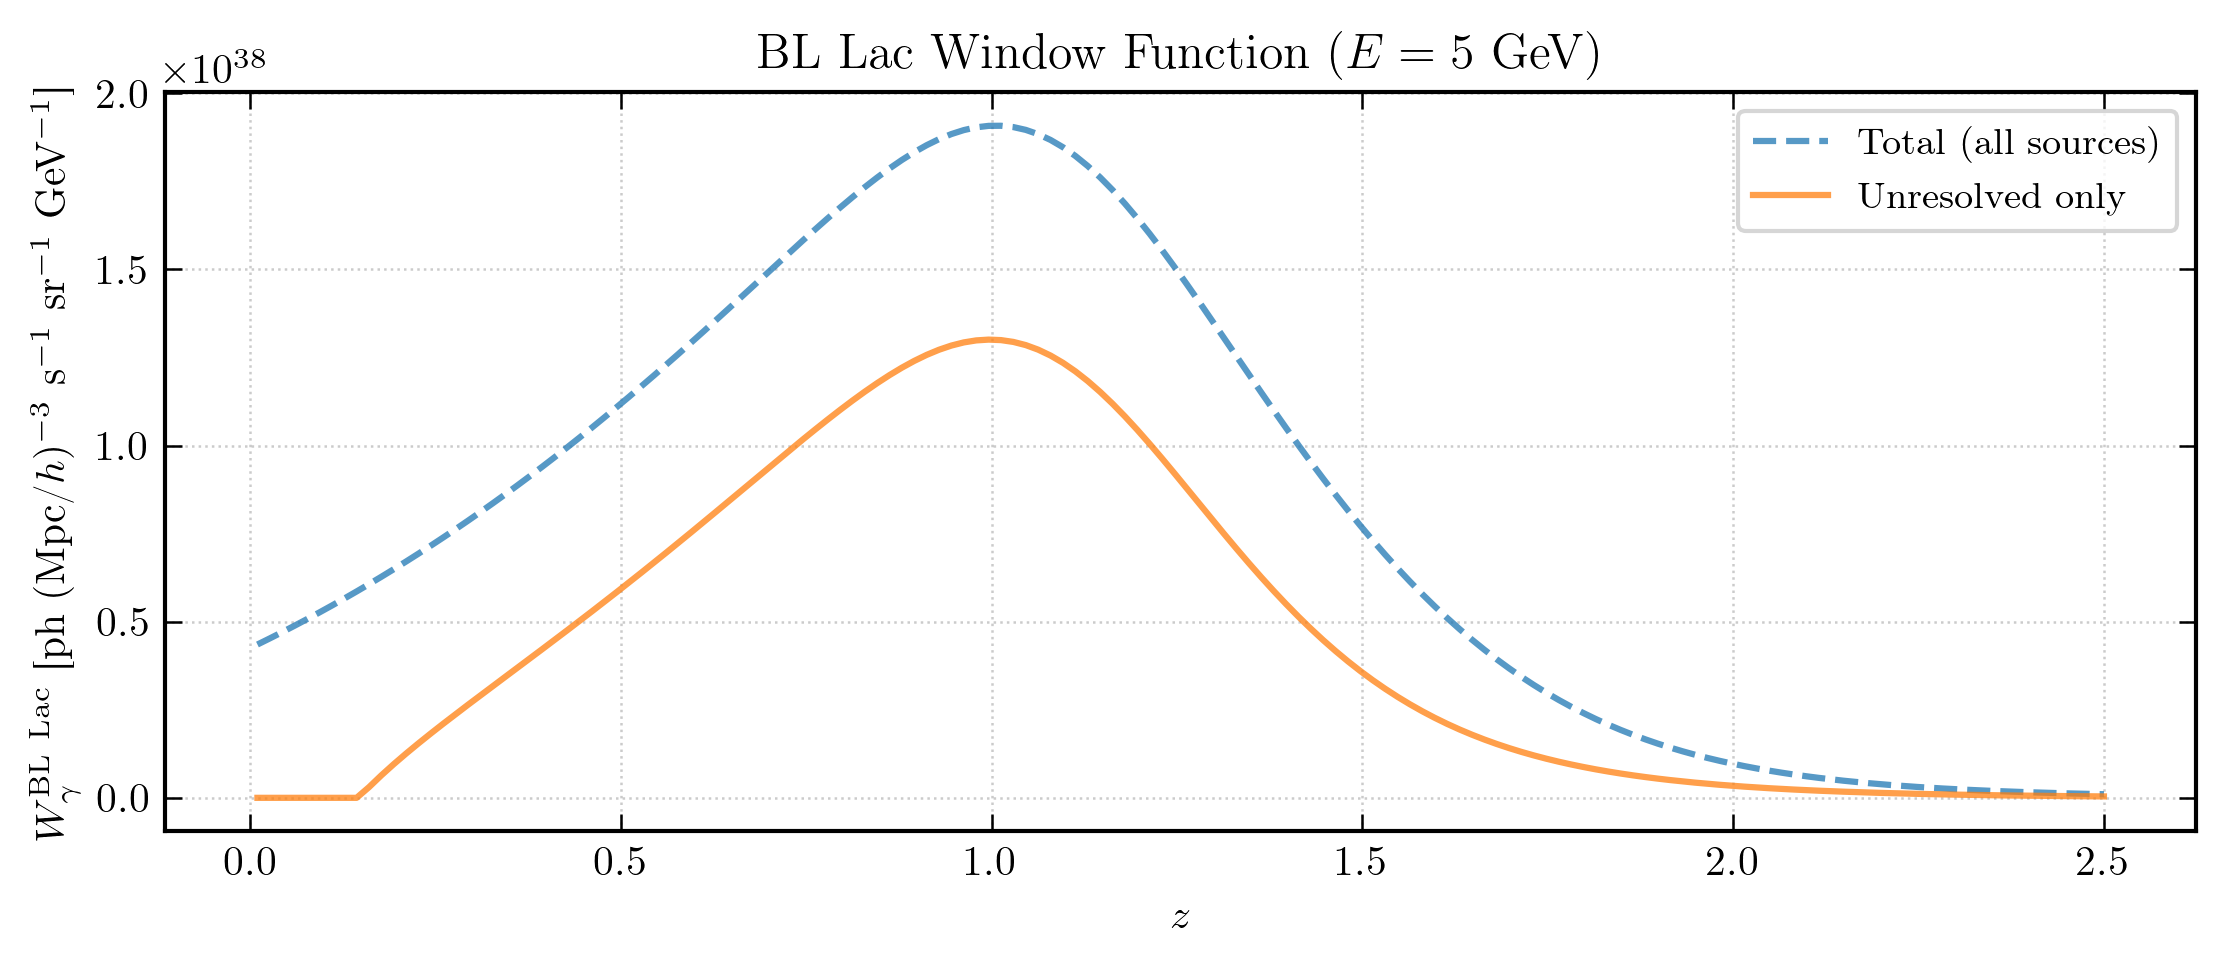

In [26]:
z_w = np.linspace(0.01, 2.5, 150)
W_unres = np.array([astro.W_gamma_astro(5.0, z, 'BL_Lac', unresolved_only=True) for z in z_w])
W_total = np.array([astro.W_gamma_astro(5.0, z, 'BL_Lac', unresolved_only=False) for z in z_w])

fig, ax = sty.textwidth_figure(7)
ax.plot(z_w, W_total, **sty.MODEL_STYLE, label='Total (all sources)')
ax.plot(z_w, W_unres, **sty.FIT_STYLE, label='Unresolved only')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$W_\gamma^\mathrm{BL\ Lac}$ [ph (Mpc/$h$)$^{-3}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$]')
ax.set_title('BL Lac Window Function ($E = 5$ GeV)'); ax.legend(); fig.tight_layout()

## 4. Mean Unresolved Intensity

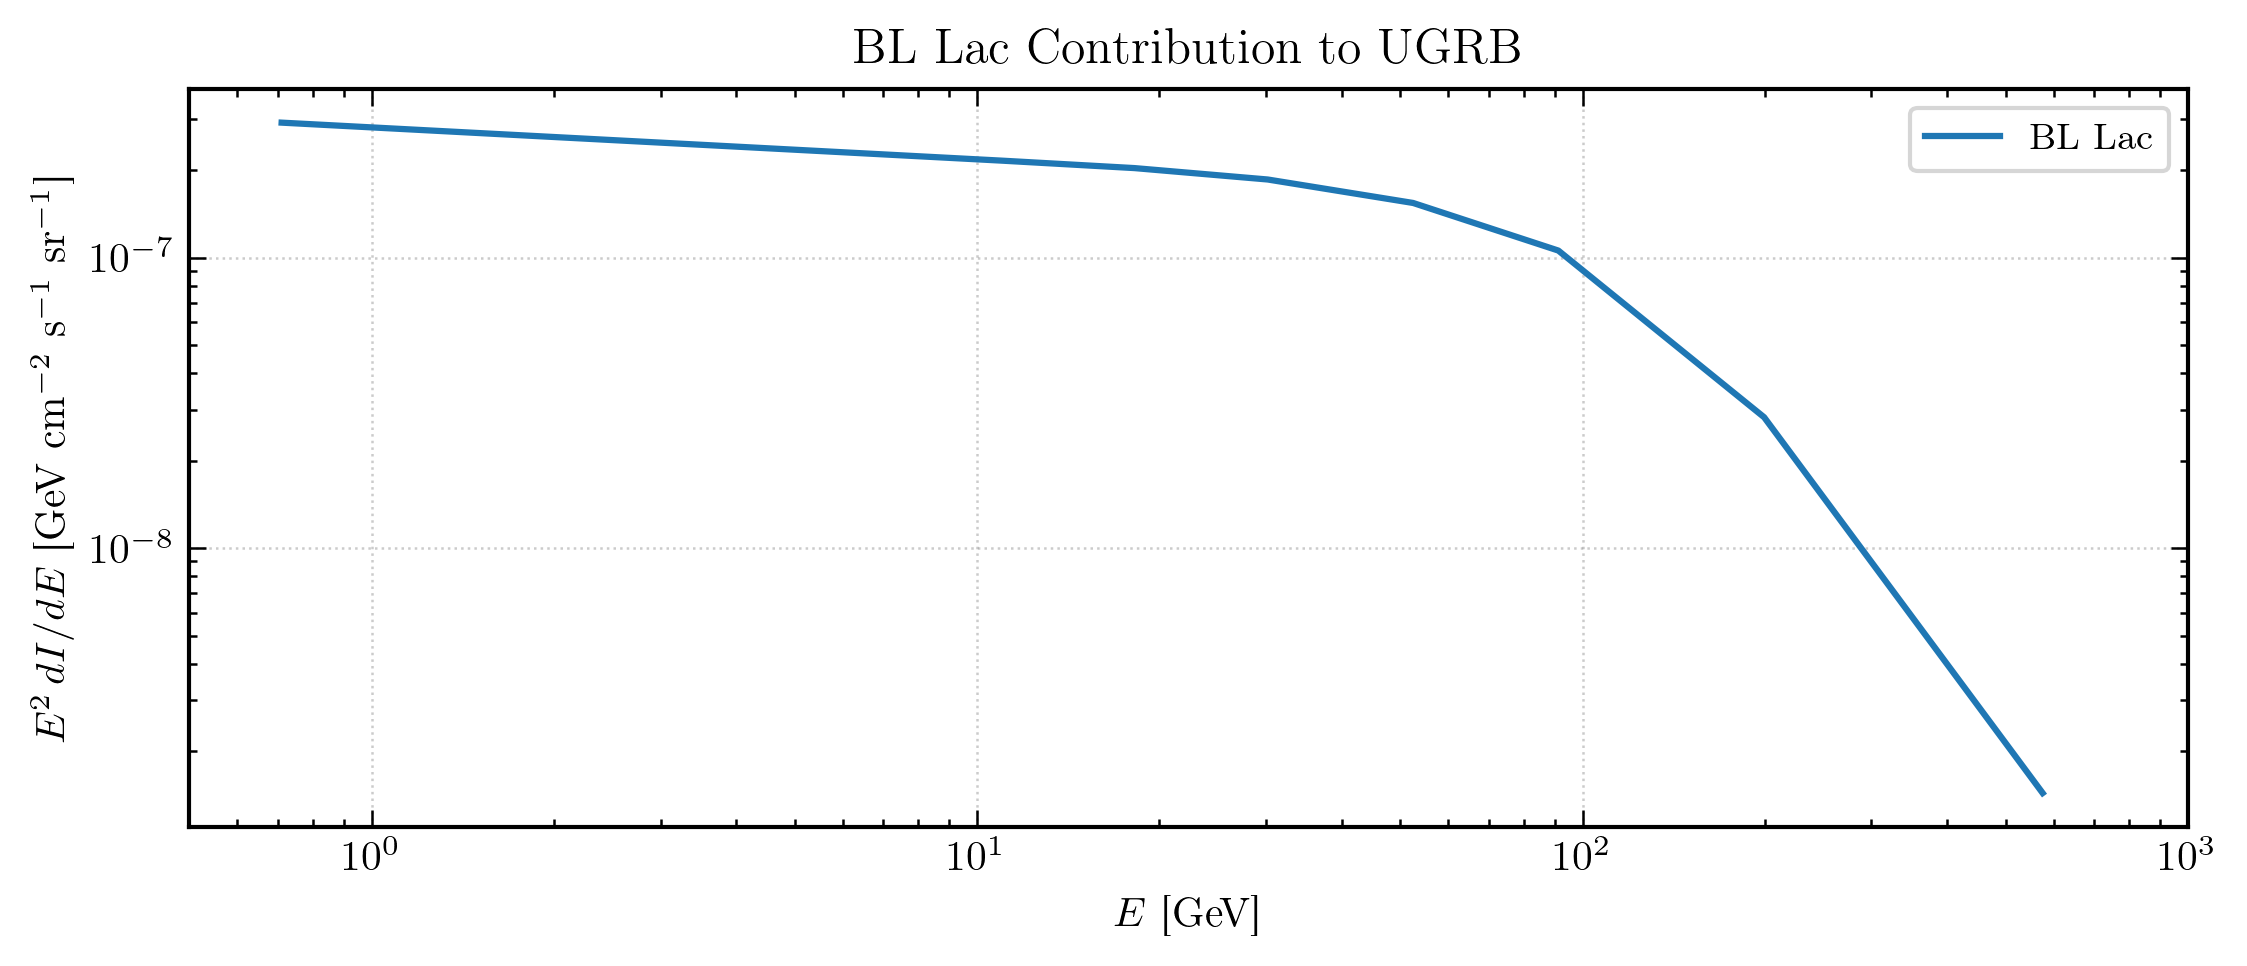

In [27]:
E_arr = cfg.FERMI_E_B
I_bl = np.array([astro.mean_intensity(E, 'BL_Lac') for E in E_arr])
fig, ax = sty.textwidth_figure(7)
ax.loglog(E_arr, E_arr**2 * I_bl, 'C0', lw=sty.LW_STANDARD, label='BL Lac')
ax.set_xlabel('$E$ [GeV]'); ax.set_ylabel(r'$E^2\,dI/dE$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
ax.set_title('BL Lac Contribution to UGRB'); ax.set_xlim(0.5, 1000); ax.legend(); fig.tight_layout()

## 5. Effective Bias

<>:6: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:6: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
/tmp/ipykernel_715807/2896739906.py:6: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  ax.set_title('BL Lac Effective Bias (fixed halo mass $M = 10^{13}\,M_\odot$)')


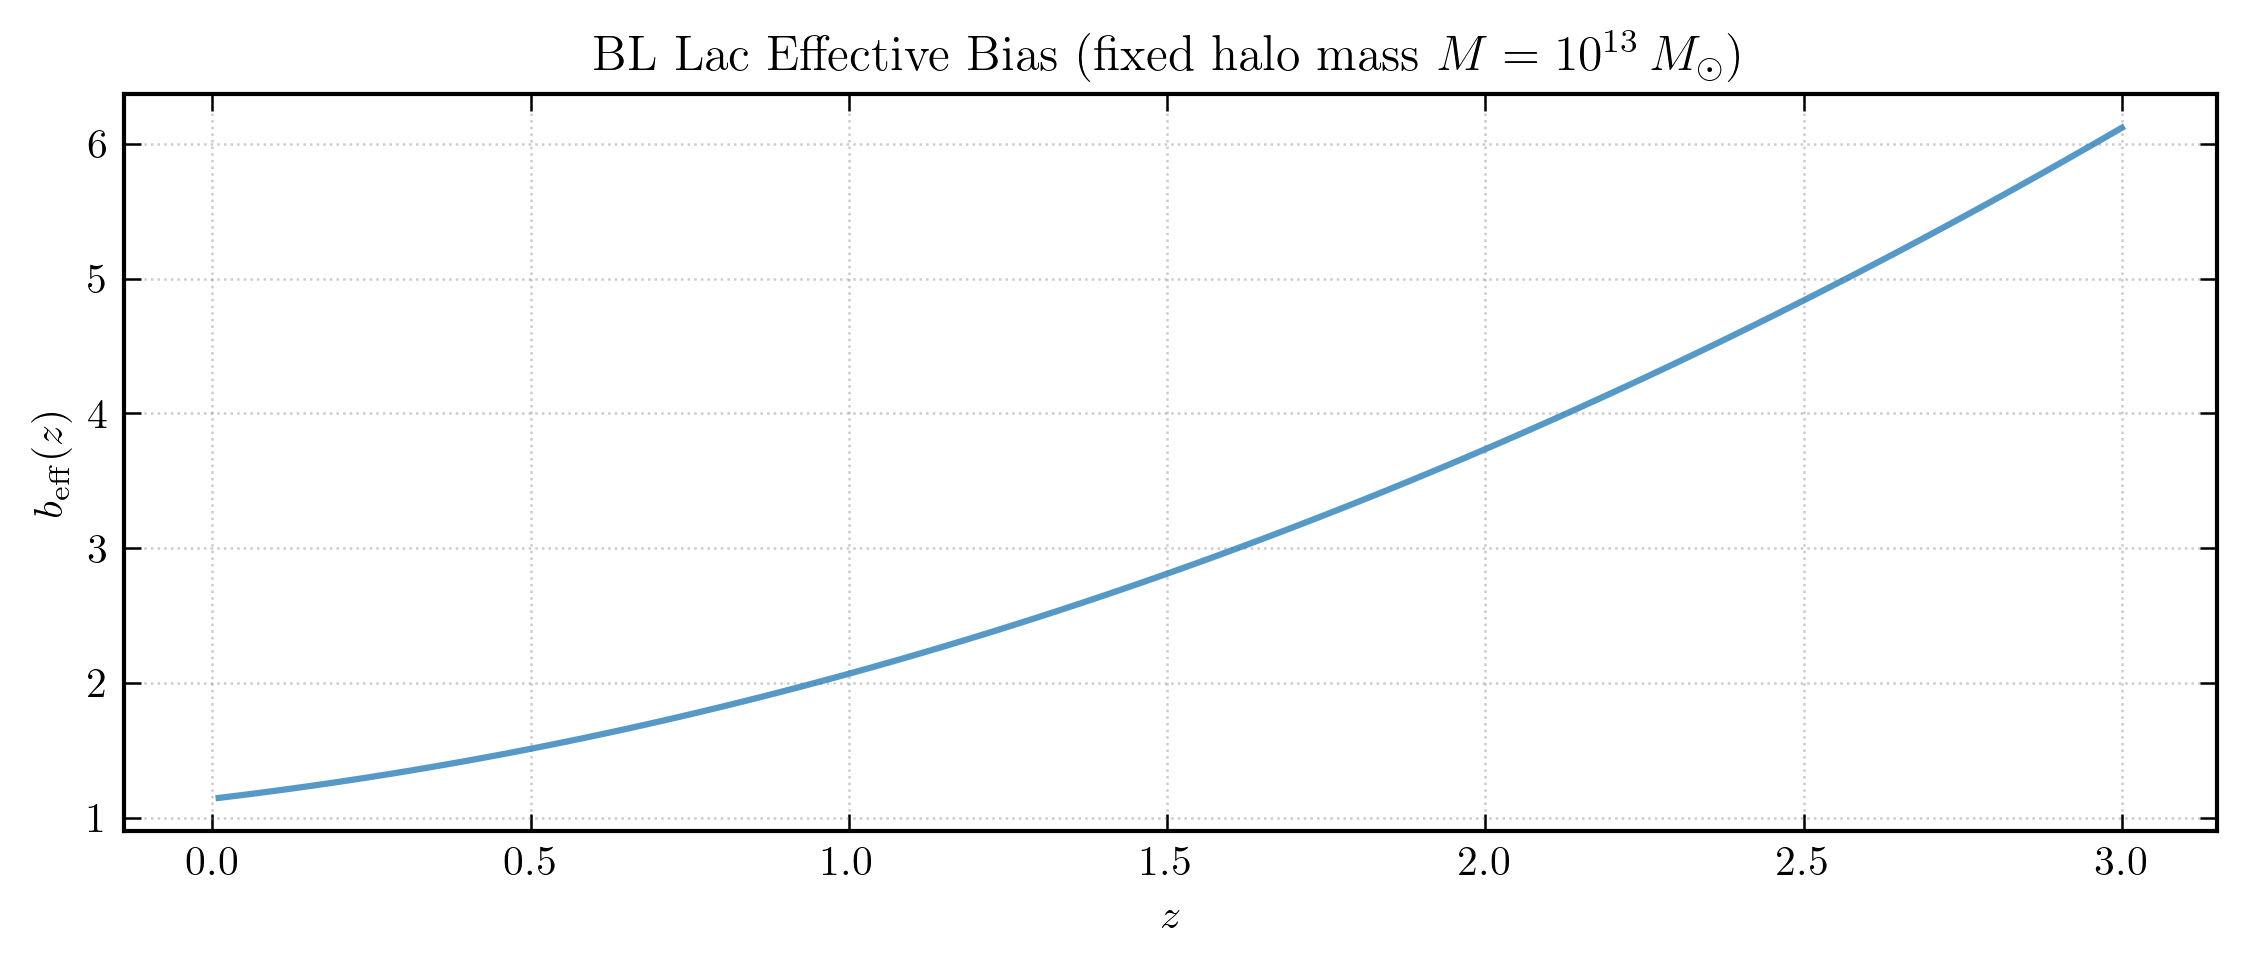

In [28]:
z_b = np.linspace(0.01, 3.0, 100)
b_bl = np.array([astro.bias_astro(z, 'BL_Lac') for z in z_b])
fig, ax = sty.textwidth_figure(7)
ax.plot(z_b, b_bl, **sty.FIT_STYLE)
ax.set_xlabel('$z$'); ax.set_ylabel(r'$b_\mathrm{eff}(z)$')
ax.set_title('BL Lac Effective Bias (fixed halo mass $M = 10^{13}\,M_\odot$)')
fig.tight_layout()